  ## **EcoRoute: Air Quality Prediction & Health Advisory System**



#PROBLEM STATEMENT:
This project predicts AQI using machine learning and provides health-based recommendations.



## Data Loading


In [4]:
from google.colab import files
uploaded = files.upload()

Saving india_city_aqi_2015_2023.csv to india_city_aqi_2015_2023.csv


In [5]:
import pandas as pd

df = pd.read_csv("india_city_aqi_2015_2023.csv")
df.head()

,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory


## Data Understanding

In [6]:
df.columns

Index(['city', 'date', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi',
       'aqi_category'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB


## Feature Selection

In [8]:
df = df[['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']]

## Data Analysis

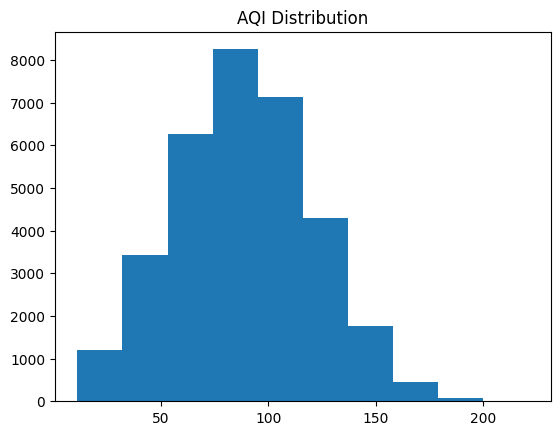

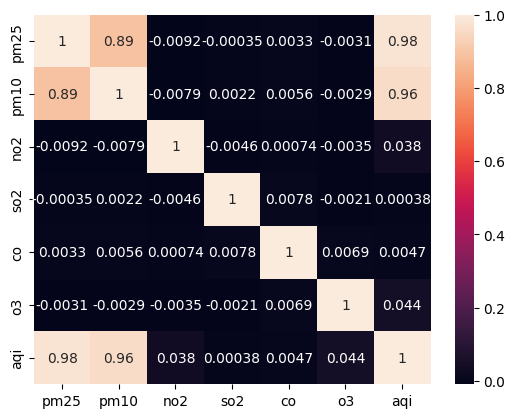

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# AQI distribution
plt.hist(df['aqi'])
plt.title("AQI Distribution")
plt.show()

# Correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

## Machine Learning Model

In [21]:
from sklearn.model_selection import train_test_split

X = df[['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']]
y = df['aqi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

## Prediction

In [23]:
pred = model.predict(X_test)
print(pred[:5])

[103.28  60.73 133.53  74.91 133.54]


## Risk & Recommendation System

In [24]:
def get_risk(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

In [25]:
def suggest(aqi):
    if aqi <= 50:
        return "Safe to go outside"
    elif aqi <= 100:
        return "Okay for outdoor activity"
    elif aqi <= 150:
        return "Limit outdoor activity"
    elif aqi <= 200:
        return "Avoid outdoor activity"
    else:
        return "Stay indoors and wear mask"

## Final Output

In [26]:
import pandas as pd

sample = pd.DataFrame([[120, 180, 40, 10, 0.8, 30]],
                      columns=['pm25', 'pm10', 'no2', 'so2', 'co', 'o3'])

aqi = model.predict(sample)[0]

print("Predicted AQI:", aqi)
print("Risk Level:", get_risk(aqi))
print("Advice:", suggest(aqi))

Predicted AQI: 120.86
Risk Level: Unhealthy for Sensitive Groups
Advice: Limit outdoor activity


##MODEL EVALUATION


In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 0.6463081837541833
R2 Score: 0.9992171970146915


## Feature Importance


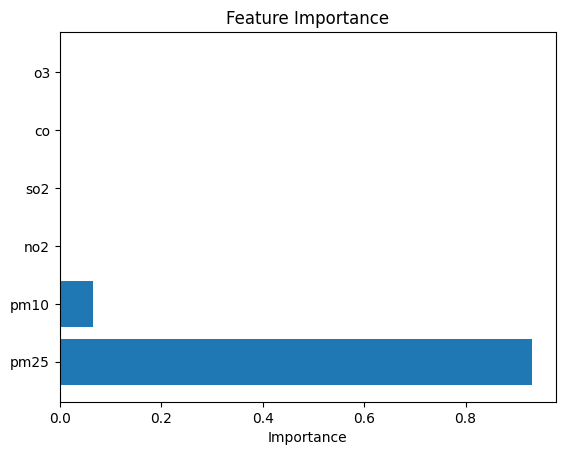

In [28]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

##VISUALIZATION

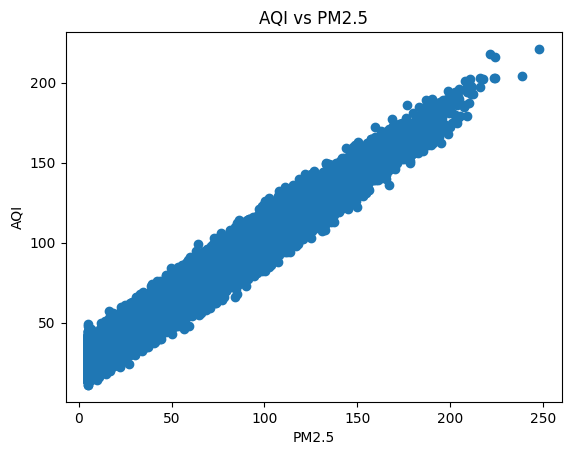

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df['pm25'], df['aqi'])
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("AQI vs PM2.5")
plt.show()

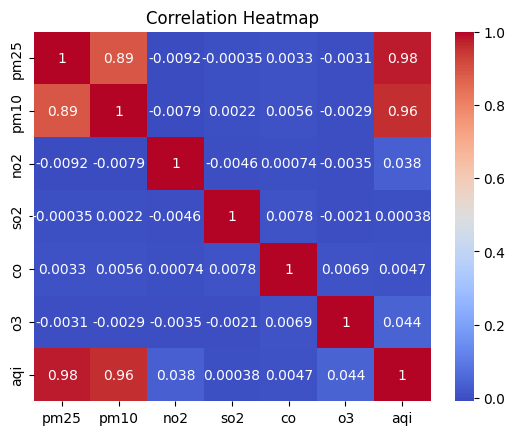

In [18]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Project Insights

- PM2.5 and PM10 are the most influential pollutants affecting AQI
- Strong positive correlation exists between PM2.5 and AQI (~0.98)
- As PM2.5 increases, AQI increases sharply, indicating worsening air quality
- Gaseous pollutants (NO2, CO) have lower but noticeable impact
- High AQI levels indicate unsafe outdoor conditions and health risks
- The model predicts AQI with high accuracy (R2 Score ~0.99)